In [2]:
import pandas as pd

# Load the OPTED dataset into a DataFrame
df_opted = pd.read_csv('/content/OPTED-Dictionary.csv')

# Display the first 5 rows of the DataFrame
display(df_opted.head())

,Word,Count,POS,Definition
0,A,1,"""""","""The first letter of the English and of many o..."
1,A,1,"""""","""The name of the sixth tone in the model major..."
2,A,1,"""""","""An adjective commonly called the indefinite ..."
3,A,1,"""""","""In each; to or for each; as """"""""twenty leagu..."
4,A,1,"""prep.""","""In; on; at; by."""


In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
# Get the unique values and their frequencies from the 'Word' column
word_frequencies = df_opted['Word'].value_counts()

# Display the frequencies
display(word_frequencies)

,count
Word,
#NAME?,207
Run,72
Set,59
Light,47
Round,46
...,...
Glycerin,1
Glyceride,1
Glyceric,1


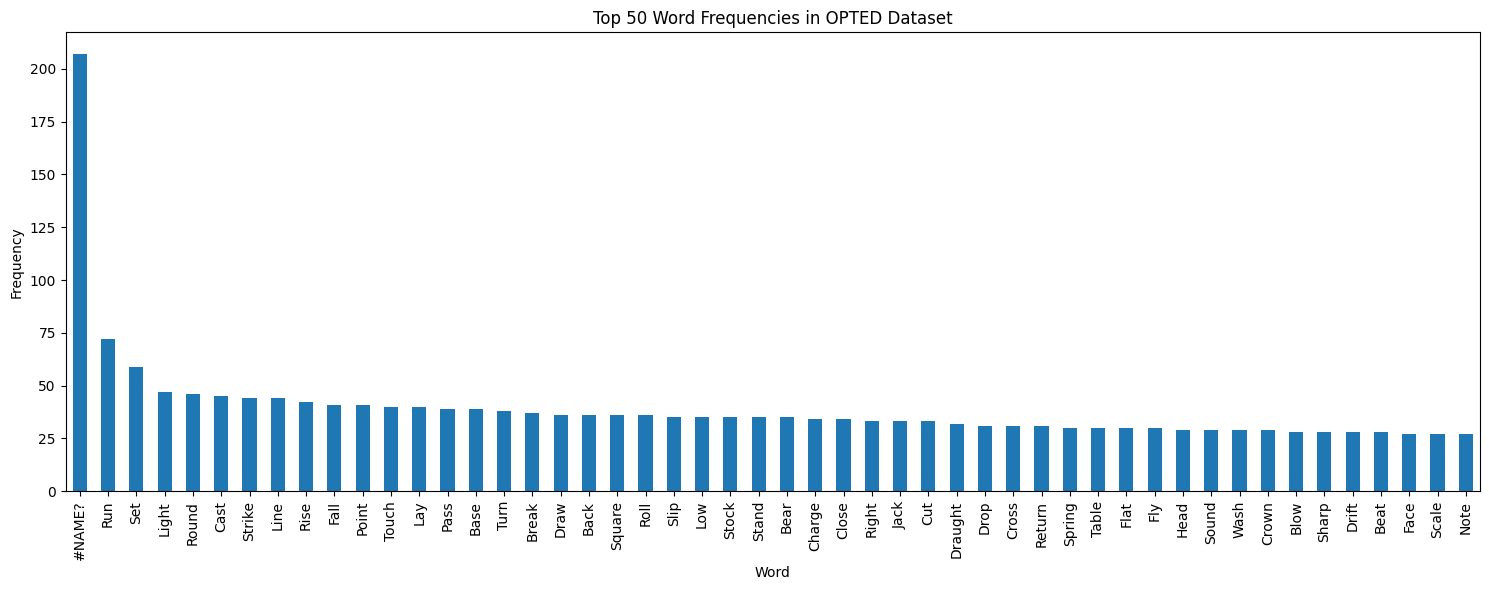

In [4]:
import matplotlib.pyplot as plt

# Plot the word frequencies
plt.figure(figsize=(15, 6))
word_frequencies.head(50).plot(kind='bar') # Plotting the top 50 words for better readability
plt.title('Top 50 Word Frequencies in OPTED Dataset')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [5]:
# Remove the '#NAME?' entry from the word_frequencies to create a new filtered Series
filtered_word_frequencies = word_frequencies[word_frequencies.index != '#NAME?']

# Display the head of the filtered frequencies to confirm
display(filtered_word_frequencies.head())

,count
Word,
Run,72
Set,59
Light,47
Round,46
Cast,45


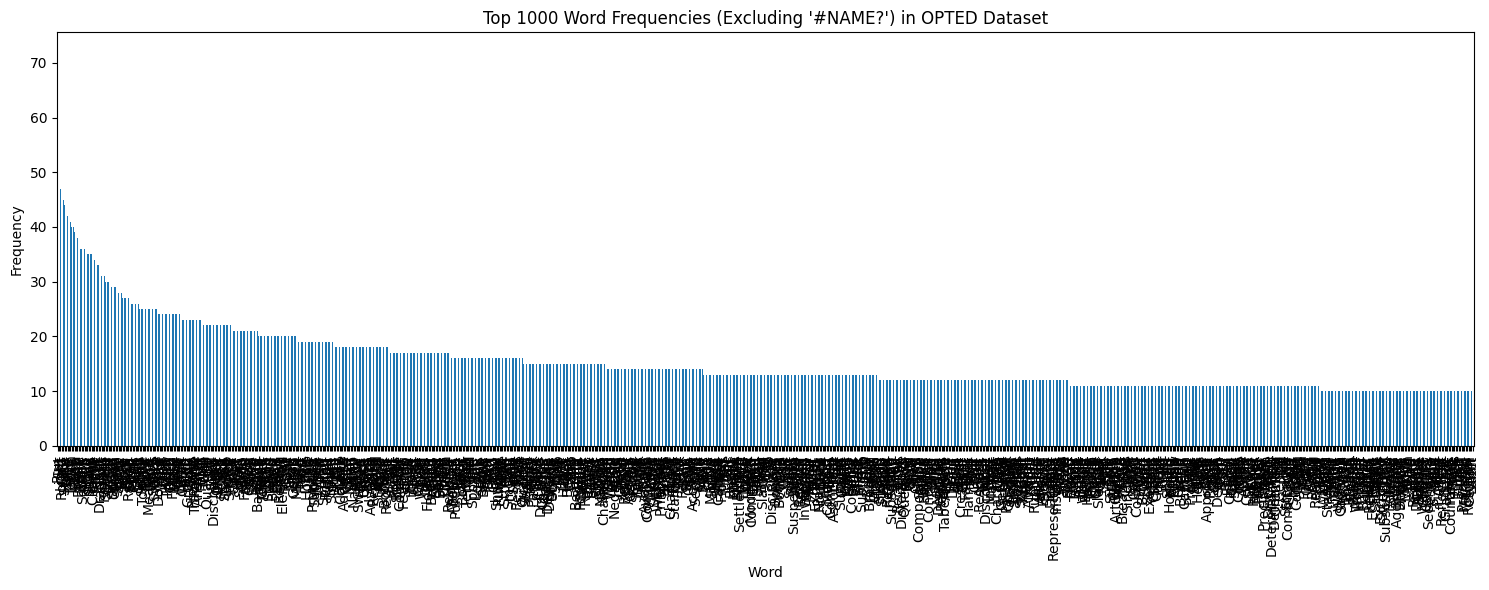

In [6]:
import matplotlib.pyplot as plt

# Plot the filtered word frequencies (top 50)
plt.figure(figsize=(15, 6))
filtered_word_frequencies.head(1000).plot(kind='bar')
plt.title('Top 1000 Word Frequencies (Excluding \'#NAME?\') in OPTED Dataset')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [10]:
# Calculate the median of the filtered word frequencies
median_frequency = filtered_word_frequencies.median()

print(f"The median frequency of words (excluding '#NAME?') is: {median_frequency}")

The median frequency of words (excluding '#NAME?') is: 1.0


In [11]:
# Calculate the mean of the filtered word frequencies
mean_frequency = filtered_word_frequencies.mean()

print(f"The mean frequency of words (excluding '#NAME?') is: {mean_frequency:.2f}")

The mean frequency of words (excluding '#NAME?') is: 1.58


### Word Frequency in Definitions

Now, let's analyze the words used within the 'Definition' column to understand the vocabulary used in the definitions themselves.

In [7]:
import re

# Extract definitions and combine them into a single string
all_definitions_text = ' '.join(df_opted['Definition'].dropna().astype(str))

# Tokenize the text into words, converting to lowercase and removing punctuation
# Using a regular expression to find sequences of letters as words
words_in_definitions = re.findall(r'\b[a-z]+\b', all_definitions_text.lower())

# Calculate the frequency of each word
definition_word_frequencies = pd.Series(words_in_definitions).value_counts()

# Display the top 20 most frequent words in definitions
print("Top 20 words used in the 'Definition' column:")
display(definition_word_frequencies)

Top 20 words used in the 'Definition' column:


,count
of,131548
a,114440
the,111251
to,97431
or,88696
...,...
zymogen,1
gonad,1
adansonii,1
oarsmen,1


### Filtering Stopwords from Definition Keywords

To get a better sense of unique terminology and keywords in the definitions, we can remove common English stopwords (e.g., 'the', 'a', 'of') from the word frequency list.

In [8]:
# Import NLTK for stopword removal
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded (this only needs to run once)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Get the list of English stopwords
english_stopwords = set(stopwords.words('english'))

# Filter out stopwords from the definition_word_frequencies
filtered_definition_word_frequencies = definition_word_frequencies[~definition_word_frequencies.index.isin(english_stopwords)]

# Display the top 20 most frequent non-stopwords in definitions
print("Top 100 words used in the 'Definition' column (excluding stopwords):")
display(filtered_definition_word_frequencies)

Top 100 words used in the 'Definition' column (excluding stopwords):


,count
one,15916
see,8864
pertaining,6010
also,5975
used,5228
...,...
zymogen,1
gonad,1
adansonii,1
oarsmen,1


### Finding Similar Definitions

Now, let's identify definitions that are similar to each other. This involves transforming the text definitions into numerical vectors and then calculating a similarity metric, such as cosine similarity. Due to the large number of definitions, calculating and displaying all pairs might be too much, so we will focus on finding the most similar pairs.

### Words by Frequency in the 'Word' Column

In [14]:
print("Top words from the 'Word' column, ordered by frequency:")
display(word_frequencies.head(20)) # Displaying top 20 for brevity

Top words from the 'Word' column, ordered by frequency:


,count
Word,
#NAME?,207
Run,72
Set,59
Light,47
Round,46
Cast,45
Strike,44
Line,44
Rise,42


### Words by Frequency in the 'Definition' Column

In [15]:
print("Top words from the 'Definition' column, ordered by frequency:")
display(definition_word_frequencies.head(20)) # Displaying top 20 for brevity

Top words from the 'Definition' column, ordered by frequency:


,count
of,131548
a,114440
the,111251
to,97431
or,88696
as,38989
in,37961
and,26237
an,18943
by,17799


In [16]:
# Get the set of words from the 'Word' column
words_in_word_column = set(df_opted['Word'].unique())

# Get the set of words from the 'Definition' column frequencies
words_in_definitions_set = set(definition_word_frequencies.index)

# Find the intersection of these two sets
common_words = words_in_word_column.intersection(words_in_definitions_set)

# Print the number of common words
print(f"Number of words common to both the 'Word' column and 'Definition' text: {len(common_words)}")

Number of words common to both the 'Word' column and 'Definition' text: 57


### Common Words Ordered by Frequency in 'Word' Column

In [17]:
# Filter word_frequencies to only include common words
common_words_in_word_freq = word_frequencies[word_frequencies.index.isin(common_words)]

# Sort by frequency in descending order
common_words_in_word_freq_sorted = common_words_in_word_freq.sort_values(ascending=False)

print("Common words ordered by frequency in the 'Word' column:")
display(common_words_in_word_freq_sorted)

Common words ordered by frequency in the 'Word' column:


,count
Word,
niere,3
ties,2
have,2
sentential,2
sarcoderma,2
neighbor,2
ical,2
lullaby,2
lucernarida,2


### Common Words Ordered by Frequency in 'Definition' Column

In [18]:
# Filter definition_word_frequencies to only include common words
common_words_in_def_freq = definition_word_frequencies[definition_word_frequencies.index.isin(common_words)]

# Sort by frequency in descending order
common_words_in_def_freq_sorted = common_words_in_def_freq.sort_values(ascending=False)

print("Common words ordered by frequency in the 'Definition' column:")
display(common_words_in_def_freq_sorted)

Common words ordered by frequency in the 'Definition' column:


,count
form,2864
has,1665
have,1430
salt,492
men,457
women,208
exciting,116
plastic,36
tried,29
starting,25


In [19]:
english_stopwords


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import normalize

# Ensure stopwords are downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

english_stopwords = set(stopwords.words('english'))

# Preprocess definitions
def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    tokens = text.split() # Tokenize
    tokens = [word for word in tokens if word not in english_stopwords] # Remove stopwords
    return ' '.join(tokens)

# Apply preprocessing to the 'Definition' column
df_opted['cleaned_definition'] = df_opted['Definition'].apply(preprocess_text)

# Filter out entries where cleaned_definition might be empty after preprocessing
cleaned_definitions = df_opted[df_opted['cleaned_definition'] != ''].copy()

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=330) # Limit features to manage memory

# Fit and transform the cleaned definitions
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_definitions['cleaned_definition'])

print("TF-IDF vectorization complete. Shape of TF-IDF matrix:", tfidf_matrix.shape)

# Calculate cosine similarity - Less memory intensive approach
# Cosine similarity is the dot product of L2-normalized vectors.
# By performing normalization and then matrix multiplication directly,
# we can ensure the resulting similarity matrix remains sparse (csr_matrix),
# which significantly reduces memory usage compared to a dense matrix.
normalized_tfidf_matrix = normalize(tfidf_matrix, norm='l2', axis=1)

# Calculate the sparse cosine similarity matrix using dot product
cosine_sim_matrix = normalized_tfidf_matrix @ normalized_tfidf_matrix.T

print("Cosine similarity matrix calculation complete. Shape:", cosine_sim_matrix.shape)
print("Note: The cosine similarity matrix is now stored as a sparse csr_matrix.")

TF-IDF vectorization complete. Shape of TF-IDF matrix: (175860, 330)
Cosine similarity matrix calculation complete. Shape: (175860, 175860)
Note: The cosine similarity matrix is now stored as a sparse csr_matrix.


In [ ]:
import scipy.sparse as sp

# Function to find the top N most similar pairs efficiently for sparse matrices
def find_top_similar_pairs(similarity_matrix, df, n=10):
    # Use scipy.sparse.find to get all non-zero elements and their coordinates
    # This extracts (row, col, value) tuples efficiently
    rows, cols, scores = sp.find(similarity_matrix)

    similar_pairs_raw = []
    # Use the original index from the filtered DataFrame for mapping
    indices = df.index.tolist()

    # Filter for unique pairs (j > i to avoid duplicates and self-similarity)
    # and store them with their original definitions
    for r, c, score in zip(rows, cols, scores):
        if r < c:  # Ensure unique pairs (e.g., (0,1) but not (1,0) or (0,0))
            # Make sure similarity score is not 1.0 (self-similarity) unless there are duplicates
            # For now, let's include all non-1.0 similarities for r < c
            if score < 0.999: # Arbitrary threshold to exclude very high self-similarity, adjust if needed
                def1 = df.loc[indices[r], 'Definition']
                def2 = df.loc[indices[c], 'Definition']
                similar_pairs_raw.append((score, def1, def2))

    # Sort by similarity score in descending order
    similar_pairs_raw.sort(key=lambda x: x[0], reverse=True)

    return similar_pairs_raw[:n]

# Find the top 10 most similar pairs
top_similarities = find_top_similar_pairs(cosine_sim_matrix, cleaned_definitions, n=10)

print("\nTop 10 Most Similar Definition Pairs:")
for i, (score, def1, def2) in enumerate(top_similarities):
    print(f"\nPair {i+1} (Similarity: {score:.4f}):")
    print(f"  Definition 1: {def1}")
    print(f"  Definition 2: {def2}")

In [9]:
import scipy.sparse

# Define the filename for the sparse TF-IDF matrix
tfidf_matrix_filename = 'tfidf_matrix.npz'

# Save the sparse TF-IDF matrix
scipy.sparse.save_npz(tfidf_matrix_filename, tfidf_matrix)

print(f"TF-IDF matrix saved to {tfidf_matrix_filename}")

TF-IDF matrix saved to tfidf_matrix.npz


In [10]:
# To demonstrate, load the saved TF-IDF matrix back
loaded_tfidf_matrix = scipy.sparse.load_npz(tfidf_matrix_filename)

print(f"Loaded TF-IDF matrix shape: {loaded_tfidf_matrix.shape}")
print(f"Is loaded matrix sparse? {scipy.sparse.issparse(loaded_tfidf_matrix)}")

Loaded TF-IDF matrix shape: (175860, 330)
Is loaded matrix sparse? True


### Bigram Analysis of Cleaned Definitions

To understand common phrases or multi-word expressions, we can perform a bigram analysis on the `cleaned_definition` column. This involves identifying pairs of consecutive words and counting their occurrences.

In [12]:
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
import nltk
import pandas as pd # Ensure pandas is imported for pd.Series

# Ensure 'punkt' and 'punkt_tab' tokenizers are downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Combine all cleaned definitions into a single string for bigram analysis
all_cleaned_definitions_text = ' '.join(cleaned_definitions['cleaned_definition'])

# Tokenize the combined text
tokens = word_tokenize(all_cleaned_definitions_text)

# Generate bigrams
bigrams = list(nltk.bigrams(tokens))

# Calculate frequency distribution of bigrams
bigram_freq_dist = FreqDist(bigrams)

print("Top 20 most common bigrams in cleaned definitions:")
display(pd.Series(bigram_freq_dist).head(20))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Top 20 most common bigrams in cleaned definitions:


,,0
first,letter,7
letter,english,27
english,many,1
many,alphabets,1
alphabets,capital,1
capital,alphabets,1
alphabets,middle,1
middle,western,1
western,europe,11
europe,also,9


### Word Cloud of Cleaned Definitions

To get a visual representation of the most frequent words in the cleaned definitions, we can generate a word cloud.

In [13]:
!pip install wordcloud matplotlib --quiet

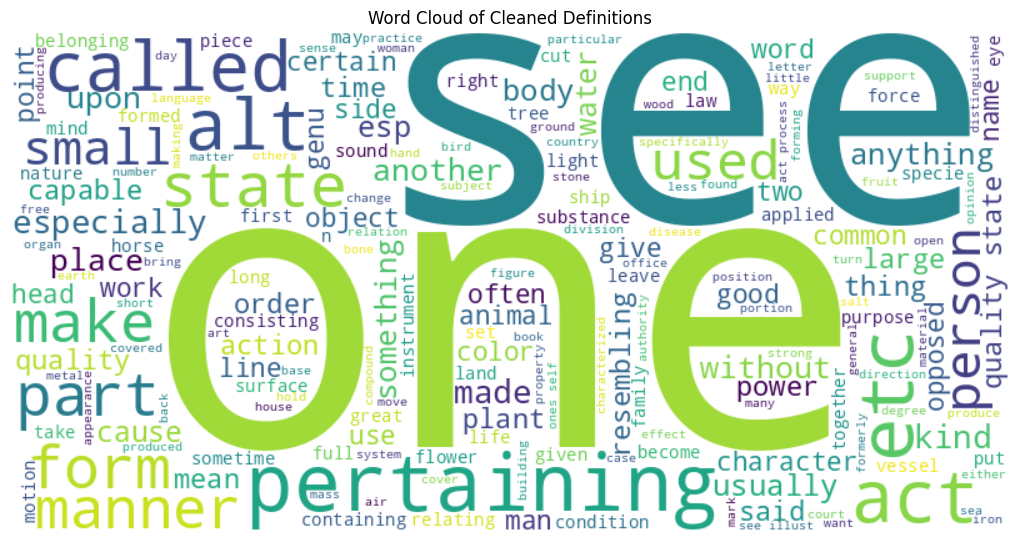

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate a word cloud image
wordcloud = WordCloud(width = 800, height = 400,
                      background_color ='white',
                      min_font_size = 10).generate(all_cleaned_definitions_text)

# Display the generated image:
plt.figure(figsize = (10, 5), facecolor = None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad = 0)
plt.title('Word Cloud of Cleaned Definitions')
plt.show()

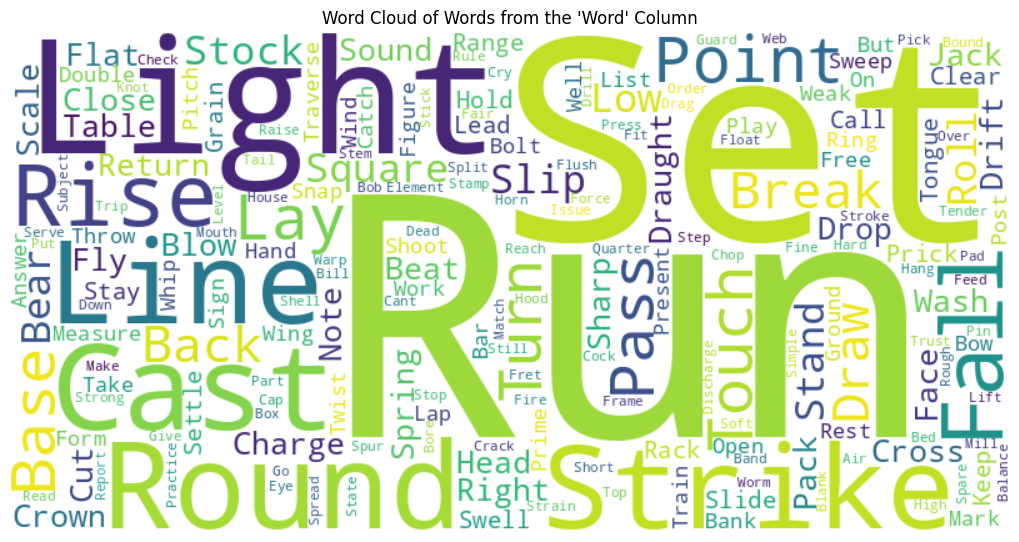

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert the filtered word frequencies Series to a dictionary
word_frequencies_dict = filtered_word_frequencies.to_dict()

# Generate a word cloud image from the frequencies
wordcloud_words = WordCloud(width = 800, height = 400,
                            background_color ='white',
                            min_font_size = 10).generate_from_frequencies(word_frequencies_dict)

# Display the generated image:
plt.figure(figsize = (10, 5), facecolor = None)
plt.imshow(wordcloud_words, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad = 0)
plt.title('Word Cloud of Words from the \'Word\' Column')
plt.show()

### 1. Distribution of Definition Lengths

Let's analyze the distribution of the lengths of the cleaned definitions. This can provide insights into the verbosity and structure of the definitions.

Descriptive statistics for definition length:


,definition_length
count,175860.000000
mean,6.110378
std,5.609038
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,79.000000


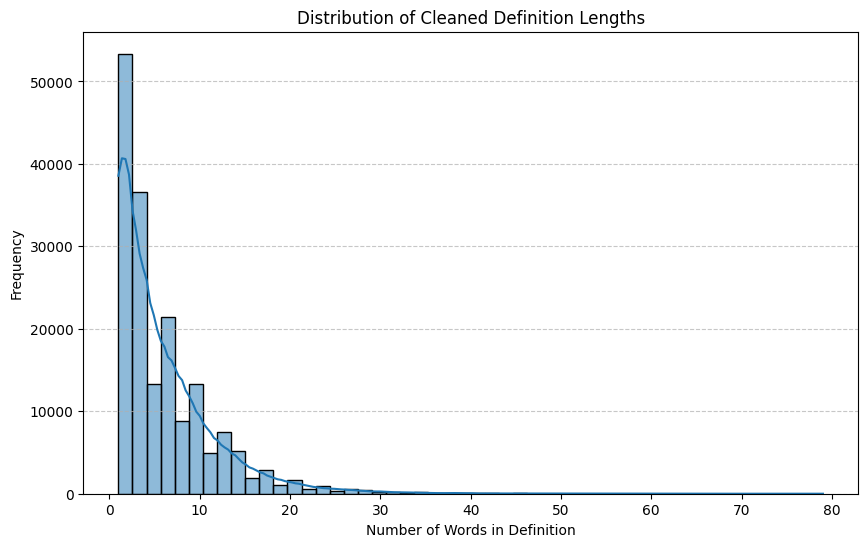

In [9]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure stopwords are downloaded (if not already present)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

english_stopwords = set(stopwords.words('english'))

# Preprocess definitions (re-define if necessary)
def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    tokens = text.split() # Tokenize
    tokens = [word for word in tokens if word not in english_stopwords] # Remove stopwords
    return ' '.join(tokens)

# Apply preprocessing to the 'Definition' column and create cleaned_definitions
# Assuming df_opted is already loaded from a previous cell
df_opted['cleaned_definition'] = df_opted['Definition'].apply(preprocess_text)
cleaned_definitions = df_opted[df_opted['cleaned_definition'] != ''].copy()

# Calculate the length of each cleaned definition (number of words)
cleaned_definitions['definition_length'] = cleaned_definitions['cleaned_definition'].apply(lambda x: len(x.split()))

# Display descriptive statistics for definition length
print("Descriptive statistics for definition length:")
display(cleaned_definitions['definition_length'].describe())

# Visualize the distribution of definition lengths
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_definitions['definition_length'], bins=50, kde=True)
plt.title('Distribution of Cleaned Definition Lengths')
plt.xlabel('Number of Words in Definition')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Part-of-Speech (POS) Tagging

Part-of-Speech tagging helps us identify the grammatical category of each word (e.g., noun, verb, adjective). This can reveal insights into the linguistic nature of the definitions.

In [13]:
import nltk

# Download the 'averaged_perceptron_tagger' and 'averaged_perceptron_tagger_eng' if not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger')

try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Top 20 Part-of-Speech Tag Frequencies:


,count
NN,480965
JJ,195647
NNS,100183
VBG,60981
RB,50409
VBD,40979
VBN,33722
VBP,32197
CD,19251
VB,15670


/tmp/ipykernel_4451/3419114614.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pos_frequencies.head(10).index, y=pos_frequencies.head(10).values, palette='viridis')


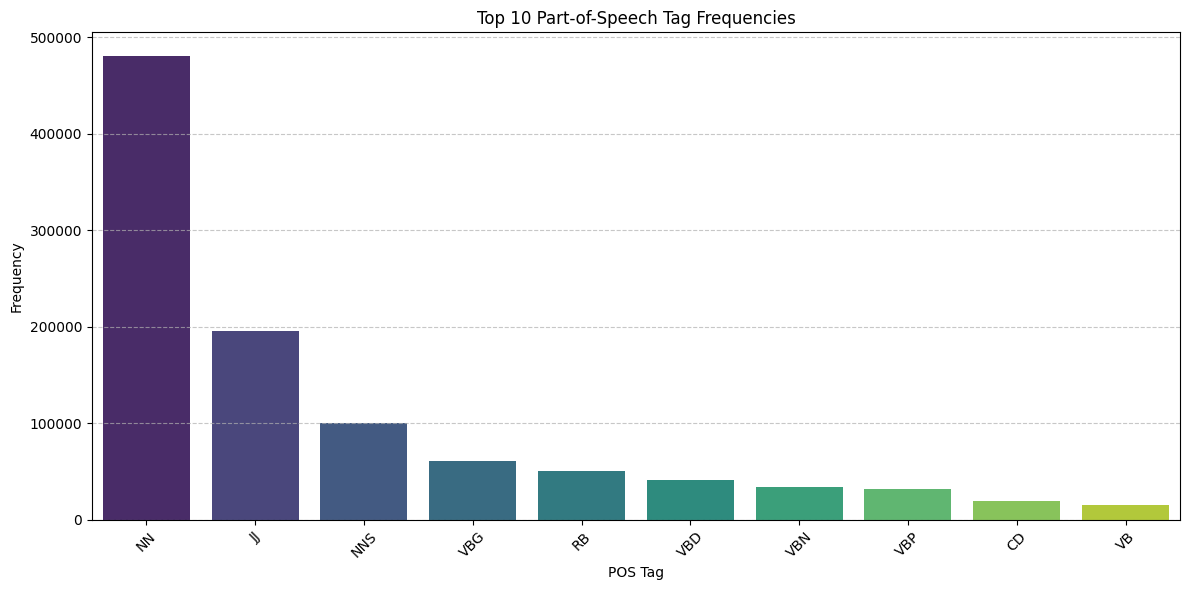

In [14]:
from nltk.tokenize import word_tokenize

# Function to perform POS tagging
def get_pos_tags(text):
    if not text: # Handle empty strings
        return []
    tokens = word_tokenize(text)
    return [tag for word, tag in nltk.pos_tag(tokens)]

# Apply POS tagging to the cleaned definitions
# Note: This might take some time due to the size of the dataset.
cleaned_definitions['pos_tags'] = cleaned_definitions['cleaned_definition'].apply(get_pos_tags)

# Flatten the list of lists of POS tags and count their frequencies
all_pos_tags = [tag for tags_list in cleaned_definitions['pos_tags'] for tag in tags_list]
pos_frequencies = pd.Series(all_pos_tags).value_counts()

print("Top 20 Part-of-Speech Tag Frequencies:")
display(pos_frequencies)

# Visualize the top 10 POS tag frequencies
plt.figure(figsize=(12, 6))
sns.barplot(x=pos_frequencies.index, y=pos_frequencies.values, palette='viridis')
plt.title('Top 10 Part-of-Speech Tag Frequencies')
plt.xlabel('POS Tag')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Named Entity Recognition (NER)

Named Entity Recognition (NER) allows us to locate and classify named entities in unstructured text into pre-defined categories such as person names, organizations, locations, medical codes, time expressions, quantities, monetary values, percentages, etc. This can help in understanding specific entities mentioned within the definitions.

In [ ]:
import spacy

# Load the medium English model. Download if not already present.
try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("Downloading spaCy model 'en_core_web_md'...")
    spacy.cli.download("en_core_web_md")
    nlp = spacy.load("en_core_web_md")

# Function to perform NER
def get_named_entities(text):
    if not text: # Handle empty strings
        return []
    doc = nlp(text)
    # Extract entities and their labels
    return [(ent.text, ent.label_) for ent in doc.ents]

# Apply NER to the cleaned definitions
# Note: This might take a significant amount of time due to the size of the dataset.
# We'll create a new column 'named_entities'
cleaned_definitions['named_entities'] = cleaned_definitions['cleaned_definition'].apply(get_named_entities)

# Flatten the list of lists of entities and count their frequencies
all_entities_with_labels = [entity for entities_list in cleaned_definitions['named_entities'] for entity in entities_list]

# Separate entities by their labels for more detailed analysis
entity_text_frequencies = pd.Series([ent[0] for ent in all_entities_with_labels]).value_counts()
entity_label_frequencies = pd.Series([ent[1] for ent in all_entities_with_labels]).value_counts()

print("Top 20 Named Entity Text Frequencies:")
display(entity_text_frequencies.head(20))

print("\nNamed Entity Label Frequencies:")
display(entity_label_frequencies)

# Visualize the top 10 Named Entity Labels
plt.figure(figsize=(12, 6))
sns.barplot(x=entity_label_frequencies.head(10).index, y=entity_label_frequencies.head(10).values, palette='viridis')
plt.title('Top 10 Named Entity Label Frequencies')
plt.xlabel('Entity Label')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
